
# Modelado, linealización y representación en variables de estado de una pierna de exoesqueleto

## Tutorial matemático y computacional en Python

**Tema:** pierna de exoesqueleto planar de dos grados de libertad  
**Articulaciones activas:** cadera y rodilla  
**Herramientas:** SymPy, NumPy, SciPy, Matplotlib  

---

## Objetivo del notebook

Construir paso a paso el modelo dinámico de una pierna de exoesqueleto similar a la figura de referencia:

- eslabón 1: muslo,
- eslabón 2: pierna o *shank*,
- articulación activa de cadera,
- articulación activa de rodilla,
- movimiento restringido al plano sagital.

El notebook desarrolla:

1. Definición de coordenadas generalizadas.
2. Modelo geométrico.
3. Energías cinética y potencial.
4. Ecuaciones dinámicas tipo manipulador:
   $$
   \mathbf{M}(\mathbf{q})\ddot{\mathbf{q}}
   +
   \mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\dot{\mathbf{q}}
   +
   \mathbf{G}(\mathbf{q})
   =
   \boldsymbol{\tau}
   $$
5. Representación no lineal en variables de estado.
6. Linealización alrededor de un punto de operación.
7. Representación lineal:
   $$
   \delta \dot{\mathbf{x}}
   =
   \mathbf{A}\delta\mathbf{x}
   +
   \mathbf{B}\delta\mathbf{u}
   $$
8. Simulación comparativa entre el modelo no lineal y el modelo linealizado.

---

## Figura de referencia

La figura ilustra un modelo planar con dos enlaces, centros de masa, longitudes de segmentos y sensores de interacción.


![Modelo planar de pierna de exoesqueleto](attachment:image.png)

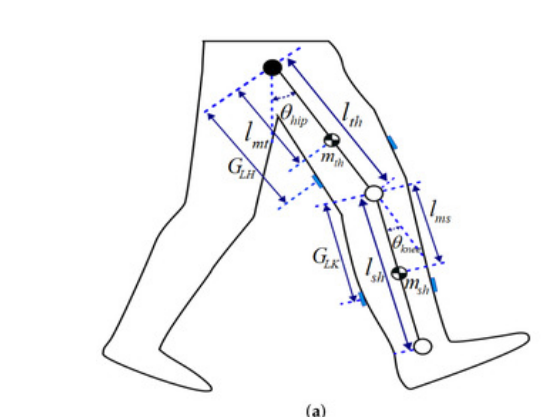

# 1. Sistema físico y supuestos de modelado

Consideramos una pierna de exoesqueleto en el plano sagital.

## 1.1. Coordenadas generalizadas

Definimos:

$$
\mathbf{q}
=
\begin{bmatrix}
\theta_h\\
\theta_k
\end{bmatrix}
$$

donde:

- $\theta_h$: ángulo de cadera.
- $\theta_k$: ángulo de rodilla.

La convención usada será:

- $\theta_h$ describe la orientación del muslo.
- $\theta_k$ describe la flexión relativa de la rodilla.
- La orientación absoluta de la pierna inferior se representa como:
  $$
  \theta_h-\theta_k
  $$

Esta convención es común en modelos de exoesqueleto de dos enlaces cuando la rodilla flexiona en sentido opuesto a la rotación positiva del muslo.

---

## 1.2. Parámetros físicos

| Símbolo | Descripción |
|---|---|
| $m_{th}$ | masa del muslo del exoesqueleto |
| $m_{sh}$ | masa de la pierna inferior o shank |
| $l_{th}$ | longitud del muslo |
| $l_{sh}$ | longitud del shank |
| $l_{mt}$ | distancia desde la cadera al centro de masa del muslo |
| $l_{ms}$ | distancia desde la rodilla al centro de masa del shank |
| $I_{th}$ | inercia rotacional del muslo respecto a su centro de masa |
| $I_{sh}$ | inercia rotacional del shank respecto a su centro de masa |
| $g$ | gravedad |

---

## 1.3. Entradas de control

Las entradas son torques articulares:

$$
\boldsymbol{\tau}
=
\begin{bmatrix}
\tau_h\\
\tau_k
\end{bmatrix}
$$

donde:

- $\tau_h$: torque aplicado en la cadera.
- $\tau_k$: torque aplicado en la rodilla.

En este tutorial se modela inicialmente la pierna sin interacción humano-exoesqueleto.

# 2. Modelo geométrico

Definimos un sistema de coordenadas en el plano.

Tomamos como referencia la cadera. La posición del centro de masa del muslo es:

$$
\mathbf{r}_{th}
=
\begin{bmatrix}
l_{mt}\sin(\theta_h)\\
-l_{mt}\cos(\theta_h)
\end{bmatrix}
$$

La posición de la rodilla es:

$$
\mathbf{r}_{knee}
=
\begin{bmatrix}
l_{th}\sin(\theta_h)\\
-l_{th}\cos(\theta_h)
\end{bmatrix}
$$

La posición del centro de masa del shank es:

$$
\mathbf{r}_{sh}
=
\mathbf{r}_{knee}
+
\begin{bmatrix}
l_{ms}\sin(\theta_h-\theta_k)\\
-l_{ms}\cos(\theta_h-\theta_k)
\end{bmatrix}
$$

Por tanto:

$$
\mathbf{r}_{sh}
=
\begin{bmatrix}
l_{th}\sin(\theta_h)+l_{ms}\sin(\theta_h-\theta_k)\\
-l_{th}\cos(\theta_h)-l_{ms}\cos(\theta_h-\theta_k)
\end{bmatrix}
$$

Las velocidades se obtienen derivando respecto al tiempo:

$$
\dot{\mathbf{r}}_{th}
=
\frac{\partial \mathbf{r}_{th}}{\partial \mathbf{q}}
\dot{\mathbf{q}}
$$

$$
\dot{\mathbf{r}}_{sh}
=
\frac{\partial \mathbf{r}_{sh}}{\partial \mathbf{q}}
\dot{\mathbf{q}}
$$

Las velocidades angulares absolutas son:

$$
\omega_{th}=\dot{\theta}_h
$$

$$
\omega_{sh}=\dot{\theta}_h-\dot{\theta}_k
$$

In [1]:
# ============================================================
# 1. Importar librerías
# ============================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import StateSpace, lsim

sp.init_printing()
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
# ============================================================
# 2. Definir variables simbólicas
# ============================================================

theta_h, theta_k = sp.symbols("theta_h theta_k", real=True)
dtheta_h, dtheta_k = sp.symbols("dtheta_h dtheta_k", real=True)
ddtheta_h, ddtheta_k = sp.symbols("ddtheta_h ddtheta_k", real=True)

m_th, m_sh = sp.symbols("m_th m_sh", positive=True, real=True)
l_th, l_sh = sp.symbols("l_th l_sh", positive=True, real=True)
l_mt, l_ms = sp.symbols("l_mt l_ms", positive=True, real=True)
I_th, I_sh = sp.symbols("I_th I_sh", positive=True, real=True)
g = sp.symbols("g", positive=True, real=True)

tau_h, tau_k = sp.symbols("tau_h tau_k", real=True)

q = sp.Matrix([theta_h, theta_k])
dq = sp.Matrix([dtheta_h, dtheta_k])
ddq = sp.Matrix([ddtheta_h, ddtheta_k])
tau = sp.Matrix([tau_h, tau_k])

display(q)
display(dq)
display(tau)

⎡θₕ⎤
⎢  ⎥
⎣θₖ⎦

⎡dthetaₕ⎤
⎢       ⎥
⎣dthetaₖ⎦

⎡τₕ⎤
⎢  ⎥
⎣τₖ⎦

In [3]:
# ============================================================
# 3. Cinemática directa de centros de masa
# ============================================================

r_th = sp.Matrix([
    l_mt * sp.sin(theta_h),
    -l_mt * sp.cos(theta_h)
])

r_knee = sp.Matrix([
    l_th * sp.sin(theta_h),
    -l_th * sp.cos(theta_h)
])

r_sh = r_knee + sp.Matrix([
    l_ms * sp.sin(theta_h - theta_k),
    -l_ms * sp.cos(theta_h - theta_k)
])

J_th = r_th.jacobian(q)
J_sh = r_sh.jacobian(q)

v_th = J_th * dq
v_sh = J_sh * dq

print("r_th =")
display(r_th)

print("r_sh =")
display(r_sh)

print("J_th =")
display(J_th)

print("J_sh =")
display(J_sh)

r_th =


⎡lₘₜ⋅sin(θₕ) ⎤
⎢            ⎥
⎣-lₘₜ⋅cos(θₕ)⎦

r_sh =


⎡lₘₛ⋅sin(θₕ - θₖ) + lₜₕ⋅sin(θₕ) ⎤
⎢                               ⎥
⎣-lₘₛ⋅cos(θₕ - θₖ) - lₜₕ⋅cos(θₕ)⎦

J_th =


⎡lₘₜ⋅cos(θₕ)  0⎤
⎢              ⎥
⎣lₘₜ⋅sin(θₕ)  0⎦

J_sh =


⎡lₘₛ⋅cos(θₕ - θₖ) + lₜₕ⋅cos(θₕ)  -lₘₛ⋅cos(θₕ - θₖ)⎤
⎢                                                 ⎥
⎣lₘₛ⋅sin(θₕ - θₖ) + lₜₕ⋅sin(θₕ)  -lₘₛ⋅sin(θₕ - θₖ)⎦

# 3. Energía cinética y potencial

## 3.1. Energía cinética

La energía cinética total es:

$$
T = T_{th}+T_{sh}
$$

con:

$$
T_{th}
=
\frac{1}{2}m_{th}\dot{\mathbf{r}}_{th}^T\dot{\mathbf{r}}_{th}
+
\frac{1}{2}I_{th}\dot{\theta}_h^2
$$

y:

$$
T_{sh}
=
\frac{1}{2}m_{sh}\dot{\mathbf{r}}_{sh}^T\dot{\mathbf{r}}_{sh}
+
\frac{1}{2}I_{sh}(\dot{\theta}_h-\dot{\theta}_k)^2
$$

## 3.2. Energía potencial

Si el eje vertical positivo apunta hacia arriba y las coordenadas verticales anteriores son negativas hacia abajo:

$$
V = m_{th}g\,y_{th}+m_{sh}g\,y_{sh}
$$

## 3.3. Lagrangiano

$$
L = T - V
$$

In [4]:
# ============================================================
# 4. Energías
# ============================================================

omega_th = dtheta_h
omega_sh = dtheta_h - dtheta_k

T_th = sp.Rational(1, 2) * m_th * (v_th.dot(v_th)) + sp.Rational(1, 2) * I_th * omega_th**2
T_sh = sp.Rational(1, 2) * m_sh * (v_sh.dot(v_sh)) + sp.Rational(1, 2) * I_sh * omega_sh**2

T = sp.simplify(T_th + T_sh)
V = sp.simplify(m_th * g * r_th[1] + m_sh * g * r_sh[1])
L = sp.simplify(T - V)

print("Energía cinética T =")
display(sp.factor(T))

print("Energía potencial V =")
display(sp.factor(V))

print("Lagrangiano L =")
display(sp.factor(L))

Energía cinética T =


           2                                      2              2          2  ↪
Iₛₕ⋅dthetaₕ  - 2⋅Iₛₕ⋅dthetaₕ⋅dthetaₖ + Iₛₕ⋅dthetaₖ  + Iₜₕ⋅dthetaₕ  + dthetaₕ ⋅ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪    2                2                              2    2              2     ↪
↪ lₘₛ ⋅mₛₕ + 2⋅dthetaₕ ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ) + dthetaₕ ⋅lₘₜ ⋅mₜₕ + dthetaₕ ⋅lₜₕ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                              2                               ↪

↪ 2                            2                                               ↪
↪  ⋅mₛₕ - 2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ ⋅mₛₕ - 2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ) + ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪         2    2    
↪  d

Energía potencial V =


-g⋅(lₘₛ⋅mₛₕ⋅cos(θₕ - θₖ) + lₘₜ⋅mₜₕ⋅cos(θₕ) + lₜₕ⋅mₛₕ⋅cos(θₕ))

Lagrangiano L =


           2                                      2              2          2  ↪
Iₛₕ⋅dthetaₕ  - 2⋅Iₛₕ⋅dthetaₕ⋅dthetaₖ + Iₛₕ⋅dthetaₖ  + Iₜₕ⋅dthetaₕ  + dthetaₕ ⋅ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪    2                2                              2    2              2     ↪
↪ lₘₛ ⋅mₛₕ + 2⋅dthetaₕ ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ) + dthetaₕ ⋅lₘₜ ⋅mₜₕ + dthetaₕ ⋅lₜₕ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪ 2                            2                                               ↪
↪  ⋅mₛₕ - 2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ ⋅mₛₕ - 2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ) + ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪      2                                                                       ↪

↪         2    2         

# 4. Ecuaciones de Euler-Lagrange

Las ecuaciones de Euler-Lagrange son:

$$
\frac{d}{dt}
\left(
\frac{\partial L}{\partial \dot{q}_i}
\right)
-
\frac{\partial L}{\partial q_i}
=
\tau_i
$$

para:

$$
i=1,2
$$

El resultado puede organizarse en la forma estándar:

$$
\mathbf{M}(\mathbf{q})\ddot{\mathbf{q}}
+
\mathbf{h}(\mathbf{q},\dot{\mathbf{q}})
=
\boldsymbol{\tau}
$$

donde:

$$
\mathbf{h}(\mathbf{q},\dot{\mathbf{q}})
=
\mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\dot{\mathbf{q}}
+
\mathbf{G}(\mathbf{q})
$$

In [5]:
# ============================================================
# 5. Construcción simbólica de Euler-Lagrange
# ============================================================

q_symbols = [theta_h, theta_k]
dq_symbols = [dtheta_h, dtheta_k]
ddq_symbols = [ddtheta_h, ddtheta_k]

EL = []

for i in range(2):
    dL_ddqi = sp.diff(L, dq_symbols[i])

    total_dt = 0
    for j in range(2):
        total_dt += sp.diff(dL_ddqi, q_symbols[j]) * dq_symbols[j]
        total_dt += sp.diff(dL_ddqi, dq_symbols[j]) * ddq_symbols[j]

    dL_dqi = sp.diff(L, q_symbols[i])
    EL_i = sp.simplify(total_dt - dL_dqi)
    EL.append(EL_i)

EL = sp.Matrix(EL)

print("Ecuaciones Euler-Lagrange, lado izquierdo =")
display(EL)

Ecuaciones Euler-Lagrange, lado izquierdo =


⎡         ⎛               2           ⎛   2                          2⎞⎞       ↪
⎢ddthetaₕ⋅⎝Iₛₕ + Iₜₕ + lₘₜ ⋅mₜₕ + mₛₕ⋅⎝lₘₛ  + 2⋅lₘₛ⋅lₜₕ⋅cos(θₖ) + lₜₕ ⎠⎠ - ddt ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣                                       -Iₛₕ⋅ddthetaₕ + Iₛₕ⋅ddthetaₖ - ddtheta ↪

↪                                                                              ↪
↪ hetaₖ⋅(Iₛₕ + lₘₛ⋅mₛₕ⋅(lₘₛ + lₜₕ⋅cos(θₖ))) - dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅(2⋅dthetaₕ - ↪
↪                                                                              ↪
↪      2                                                  2              2     ↪
↪ ₕ⋅lₘₛ ⋅mₛₕ - ddthetaₕ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ) + ddthetaₖ⋅lₘₛ ⋅mₛₕ + dthetaₕ ⋅lₘₛ ↪

↪                                                                              ↪
↪  dthetaₖ)⋅sin(θₖ) + g⋅(lₘₛ⋅mₛₕ⋅sin(θₕ - θₖ) + lₘₜ⋅mₜₕ⋅sin(θₕ) + lₜₕ⋅mₛₕ⋅sin( ↪
↪                         

In [6]:
# ============================================================
# 6. Extraer M(q) y h(q,dq)
# ============================================================

M_sym = sp.simplify(EL.jacobian(ddq))
h_sym = sp.simplify(EL - M_sym * ddq)

print("M(q) obtenida con Lagrange =")
display(sp.factor(M_sym))

print("h(q,dq) = C(q,dq)dq + G(q) =")
display(sp.factor(h_sym))

M(q) obtenida con Lagrange =


⎡               2           ⎛   2                          2⎞                  ↪
⎢Iₛₕ + Iₜₕ + lₘₜ ⋅mₜₕ + mₛₕ⋅⎝lₘₛ  + 2⋅lₘₛ⋅lₜₕ⋅cos(θₖ) + lₜₕ ⎠  -Iₛₕ - lₘₛ⋅mₛₕ⋅ ↪
⎢                                                                              ↪
⎢                     2                                                        ↪
⎣           -Iₛₕ - lₘₛ ⋅mₛₕ - lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ)                        Iₛₕ + ↪

↪                    ⎤
↪ (lₘₛ + lₜₕ⋅cos(θₖ))⎥
↪                    ⎥
↪     2              ⎥
↪  lₘₛ ⋅mₛₕ          ⎦

h(q,dq) = C(q,dq)dq + G(q) =


⎡-dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅(2⋅dthetaₕ - dthetaₖ)⋅sin(θₖ) + g⋅(lₘₛ⋅mₛₕ⋅sin(θₕ - θₖ)  ↪
⎢                                                                              ↪
⎢                                         ⎛       2                            ↪
⎣                                 lₘₛ⋅mₛₕ⋅⎝dthetaₕ ⋅lₜₕ⋅sin(θₖ) - g⋅sin(θₕ - θ ↪

↪ + lₘₜ⋅mₜₕ⋅sin(θₕ) + lₜₕ⋅mₛₕ⋅sin(θₕ))⎤
↪                                     ⎥
↪   ⎞                                 ⎥
↪ ₖ)⎠                                 ⎦

# 5. Forma dinámica tipo manipulador

Una forma compacta del modelo es:

$$
\mathbf{M}(\mathbf{q})\ddot{\mathbf{q}}
+
\mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\dot{\mathbf{q}}
+
\mathbf{G}(\mathbf{q})
=
\boldsymbol{\tau}
$$

En este tutorial usaremos explícitamente una forma común para la pierna de dos enlaces con convención $\theta_h-\theta_k$:

$$
\mathbf{M}(\mathbf{q})
=
\begin{bmatrix}
M_{11} & M_{12}\\
M_{21} & M_{22}
\end{bmatrix}
$$

con:

$$
M_{11}
=
m_{th}l_{mt}^{2}
+
I_{th}
+
m_{sh}
\left(
l_{th}^{2}
+
l_{ms}^{2}
+
2l_{th}l_{ms}\cos\theta_k
\right)
+
I_{sh}
$$

$$
M_{12}=M_{21}
=
-
m_{sh}
\left(
l_{ms}^{2}
+
l_{th}l_{ms}\cos\theta_k
\right)
-
I_{sh}
$$

$$
M_{22}
=
m_{sh}l_{ms}^{2}
+
I_{sh}
$$

El vector gravitacional se puede escribir como:

$$
G_1
=
(m_{th}l_{mt}+m_{sh}l_{th})g\sin\theta_h
+
m_{sh}gl_{ms}\sin(\theta_h-\theta_k)
$$

$$
G_2
=
-
m_{sh}gl_{ms}\sin(\theta_h-\theta_k)
$$

Los términos de Coriolis y centrífugos pueden agruparse como:

$$
\mathbf{C}(\mathbf{q},\dot{\mathbf{q}})
=
\begin{bmatrix}
-2m_{sh}l_{th}l_{ms}\sin\theta_k\dot{\theta}_k
&
m_{sh}l_{th}l_{ms}\sin\theta_k\dot{\theta}_k\\
m_{sh}l_{th}l_{ms}\sin\theta_k\dot{\theta}_h
&
0
\end{bmatrix}
$$

---

## Nota sobre signos

La forma exacta de $\mathbf{G}$ puede cambiar de signo si se cambia:

- la dirección positiva del eje vertical,
- el sentido positivo de los ángulos,
- la definición de flexión de rodilla.

Lo importante es mantener la convención de manera consistente durante modelado, linealización y simulación.

In [7]:
# ============================================================
# 7. Definir explícitamente M, C y G con la convención usada
# ============================================================

M11 = m_th*l_mt**2 + I_th + m_sh*(l_th**2 + l_ms**2 + 2*l_th*l_ms*sp.cos(theta_k)) + I_sh
M12 = -m_sh*(l_ms**2 + l_th*l_ms*sp.cos(theta_k)) - I_sh
M22 = m_sh*l_ms**2 + I_sh

M_model = sp.Matrix([
    [M11, M12],
    [M12, M22]
])

C_model = sp.Matrix([
    [-2*m_sh*l_th*l_ms*sp.sin(theta_k)*dtheta_k,
     m_sh*l_th*l_ms*sp.sin(theta_k)*dtheta_k],
    [m_sh*l_th*l_ms*sp.sin(theta_k)*dtheta_h,
     0]
])

G_model = sp.Matrix([
    (m_th*l_mt + m_sh*l_th)*g*sp.sin(theta_h) + m_sh*g*l_ms*sp.sin(theta_h - theta_k),
    -m_sh*g*l_ms*sp.sin(theta_h - theta_k)
])

print("M_model =")
display(M_model)

print("C_model =")
display(C_model)

print("G_model =")
display(G_model)

M_model =


⎡               2           ⎛   2                          2⎞             ⎛    ↪
⎢Iₛₕ + Iₜₕ + lₘₜ ⋅mₜₕ + mₛₕ⋅⎝lₘₛ  + 2⋅lₘₛ⋅lₜₕ⋅cos(θₖ) + lₜₕ ⎠  -Iₛₕ - mₛₕ⋅⎝lₘₛ ↪
⎢                                                                              ↪
⎢                       ⎛   2                  ⎞                               ↪
⎣            -Iₛₕ - mₛₕ⋅⎝lₘₛ  + lₘₛ⋅lₜₕ⋅cos(θₖ)⎠                         Iₛₕ + ↪

↪ 2                  ⎞⎤
↪   + lₘₛ⋅lₜₕ⋅cos(θₖ)⎠⎥
↪                     ⎥
↪     2               ⎥
↪  lₘₛ ⋅mₛₕ           ⎦

C_model =


⎡-2⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅sin(θₖ)  dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅sin(θₖ)⎤
⎢                                                           ⎥
⎣ dthetaₕ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅sin(θₖ)                 0             ⎦

G_model =


⎡g⋅lₘₛ⋅mₛₕ⋅sin(θₕ - θₖ) + g⋅(lₘₜ⋅mₜₕ + lₜₕ⋅mₛₕ)⋅sin(θₕ)⎤
⎢                                                      ⎥
⎣               -g⋅lₘₛ⋅mₛₕ⋅sin(θₕ - θₖ)                ⎦

# 6. Representación no lineal en variables de estado

Definimos el estado:

$$
\mathbf{x}
=
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
x_4
\end{bmatrix}
=
\begin{bmatrix}
\theta_h\\
\theta_k\\
\dot{\theta}_h\\
\dot{\theta}_k
\end{bmatrix}
$$

y la entrada:

$$
\mathbf{u}
=
\begin{bmatrix}
\tau_h\\
\tau_k
\end{bmatrix}
$$

El modelo dinámico es:

$$
\ddot{\mathbf{q}}
=
\mathbf{M}^{-1}(\mathbf{q})
\left[
\boldsymbol{\tau}
-
\mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\dot{\mathbf{q}}
-
\mathbf{G}(\mathbf{q})
\right]
$$

La representación no lineal queda:

$$
\dot{\mathbf{x}}
=
\mathbf{f}(\mathbf{x},\mathbf{u})
=
\begin{bmatrix}
\dot{\theta}_h\\
\dot{\theta}_k\\
\ddot{\theta}_h\\
\ddot{\theta}_k
\end{bmatrix}
$$

In [8]:
# ============================================================
# 8. Construir el campo de estado no lineal f(x,u)
# ============================================================

q_vec = sp.Matrix([theta_h, theta_k])
dq_vec = sp.Matrix([dtheta_h, dtheta_k])

qdd_expr = sp.simplify(M_model.inv() * (tau - C_model*dq_vec - G_model))

x_sym = sp.Matrix([theta_h, theta_k, dtheta_h, dtheta_k])
u_sym = sp.Matrix([tau_h, tau_k])

f_sym = sp.Matrix([
    dtheta_h,
    dtheta_k,
    qdd_expr[0],
    qdd_expr[1]
])

print("qdd =")
display(qdd_expr)

print("f(x,u) =")
display(f_sym)

qdd =


⎡                            ⎛         2    ⎞ ⎛                                ↪
⎢                          - ⎝Iₛₕ + lₘₛ ⋅mₛₕ⎠⋅⎝-2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅ ↪
⎢                          ─────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢  ⎛         2                          ⎞ ⎛                                    ↪
⎢- ⎝Iₛₕ + lₘₛ ⋅mₛₕ + lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ)⎠⋅⎝-2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅sin( ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪                  2                                                           ↪
↪ sin(θₖ) + dthetaₖ ⋅lₘₛ⋅lₜ

f(x,u) =


⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                            ⎛         2    ⎞ ⎛                                ↪
⎢                          - ⎝Iₛₕ + lₘₛ ⋅mₛₕ⎠⋅⎝-2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅ ↪
⎢                          ─────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢  ⎛         2                          ⎞ ⎛                                    ↪
⎢- ⎝Iₛₕ + lₘₛ ⋅mₛₕ + lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ)⎠⋅⎝-2⋅dthetaₕ⋅dthetaₖ⋅lₘₛ⋅lₜₕ⋅mₛₕ⋅sin( ↪
⎢───────────────────────────

# 7. Linealización alrededor de un punto de operación

Sea un punto de operación:

$$
\mathbf{x}_0 =
\begin{bmatrix}
\theta_{h0}\\
\theta_{k0}\\
0\\
0
\end{bmatrix}
$$

y una entrada de equilibrio:

$$
\mathbf{u}_0 =
\mathbf{G}(\mathbf{q}_0)
$$

porque si:

$$
\dot{\mathbf{q}}_0=\mathbf{0}, \quad \ddot{\mathbf{q}}_0=\mathbf{0}
$$

entonces:

$$
\boldsymbol{\tau}_0
=
\mathbf{G}(\mathbf{q}_0)
$$

La linealización se obtiene mediante el desarrollo de Taylor de primer orden:

$$
\delta\dot{\mathbf{x}}
=
\mathbf{A}
\delta\mathbf{x}
+
\mathbf{B}
\delta\mathbf{u}
$$

donde:

$$
\mathbf{A}
=
\left.
\frac{\partial \mathbf{f}}{\partial \mathbf{x}}
\right|_{\mathbf{x}_0,\mathbf{u}_0}
$$

$$
\mathbf{B}
=
\left.
\frac{\partial \mathbf{f}}{\partial \mathbf{u}}
\right|_{\mathbf{x}_0,\mathbf{u}_0}
$$

In [9]:
# ============================================================
# 9. Jacobianos simbólicos A y B
# ============================================================

A_sym = sp.simplify(f_sym.jacobian(x_sym))
B_sym = sp.simplify(f_sym.jacobian(u_sym))

print("A(x,u) = ∂f/∂x")
display(A_sym)

print("B(x,u) = ∂f/∂u")
display(B_sym)

A(x,u) = ∂f/∂x


⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                            ⎛        ⎛         2                          ⎞   ↪
⎢                          g⋅⎝lₘₛ⋅mₛₕ⋅⎝Iₛₕ + lₘₛ ⋅mₛₕ + lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ)⎠⋅c ↪
⎢                          ─────────────────────────────────────────────────── ↪
⎢                                                             2              2 ↪
⎢                                            Iₛₕ⋅Iₜₕ + Iₛₕ⋅lₘₜ ⋅mₜₕ + Iₛₕ⋅lₜₕ  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢  ⎛        ⎛               2                                  2          2    ↪
⎢g⋅⎝lₘₛ⋅mₛₕ⋅⎝Iₛₕ + Iₜₕ + lₘₛ

B(x,u) = ∂f/∂u


⎡                                                0                             ↪
⎢                                                                              ↪
⎢                                                0                             ↪
⎢                                                                              ↪
⎢                                                   2                          ↪
⎢                                          Iₛₕ + lₘₛ ⋅mₛₕ                      ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                 2              2              2          2    2              ↪
⎢Iₛₕ⋅Iₜₕ + Iₛₕ⋅lₘₜ ⋅mₜₕ + Iₛₕ⋅lₜₕ ⋅mₛₕ + Iₜₕ⋅lₘₛ ⋅mₛₕ + lₘₛ ⋅lₘₜ ⋅mₛₕ⋅mₜₕ + lₘ ↪
⎢                                                                              ↪
⎢                                        2                                     ↪
⎢                               Iₛₕ + lₘₛ ⋅mₛₕ + lₘₛ⋅lₜₕ⋅mₛₕ⋅cos(θₖ)           ↪
⎢───────────────────────────

# 8. Asignación numérica de parámetros

Para ejecutar simulaciones usaremos valores representativos:

| Parámetro | Valor |
|---|---:|
| $m_{th}$ | 3.3 kg |
| $m_{sh}$ | 1.1 kg |
| $l_{th}$ | 0.475 m |
| $l_{sh}$ | 0.450 m |
| $l_{mt}$ | 0.360 m |
| $l_{ms}$ | 0.150 m |
| $g$ | 9.81 m/s² |

Las inercias se aproximan como barras esbeltas:

$$
I_{th} = \frac{1}{12}m_{th}l_{th}^2
$$

$$
I_{sh} = \frac{1}{12}m_{sh}l_{sh}^2
$$

In [10]:
# ============================================================
# 10. Parámetros numéricos
# ============================================================

param_values = {
    m_th: 3.3,
    m_sh: 1.1,
    l_th: 0.475,
    l_sh: 0.450,
    l_mt: 0.360,
    l_ms: 0.150,
    g: 9.81,
}

param_values[I_th] = (1/12) * param_values[m_th] * param_values[l_th]**2
param_values[I_sh] = (1/12) * param_values[m_sh] * param_values[l_sh]**2

for key, value in param_values.items():
    print(f"{key} = {value:.6f}")

m_th = 3.300000
m_sh = 1.100000
l_th = 0.475000
l_sh = 0.450000
l_mt = 0.360000
l_ms = 0.150000
g = 9.810000
I_th = 0.062047
I_sh = 0.018563


In [11]:
# ============================================================
# 11. Punto de operación
# ============================================================

theta_h0_deg = 10.0
theta_k0_deg = -20.0

theta_h0 = np.deg2rad(theta_h0_deg)
theta_k0 = np.deg2rad(theta_k0_deg)

operating_values = {
    theta_h: theta_h0,
    theta_k: theta_k0,
    dtheta_h: 0.0,
    dtheta_k: 0.0,
}

# Torque de equilibrio u0 = G(q0)
G_num_expr = G_model.subs(param_values)
G0 = np.array(G_num_expr.subs(operating_values), dtype=float).reshape(-1)

u0 = G0
x0 = np.array([theta_h0, theta_k0, 0.0, 0.0], dtype=float)

print("x0 =", x0)
print("u0 = G(q0) =", u0)
print("u0 en N·m aproximadamente")

x0 = [ 0.17453293 -0.34906585  0.          0.        ]
u0 = G(q0) = [ 3.72314229 -0.809325  ]
u0 en N·m aproximadamente


In [12]:
# ============================================================
# 12. Evaluar matrices A y B en el punto de operación
# ============================================================

subs_linearization = {}
subs_linearization.update(param_values)
subs_linearization.update(operating_values)
subs_linearization.update({
    tau_h: u0[0],
    tau_k: u0[1],
})

A_num = np.array(A_sym.subs(subs_linearization), dtype=float)
B_num = np.array(B_sym.subs(subs_linearization), dtype=float)

np.set_printoptions(precision=5, suppress=True)

print("A =")
print(A_num)

print("\nB =")
print(B_num)

A =
[[  0.        0.        1.        0.     ]
 [  0.        0.        0.        1.     ]
 [-23.08123  -3.89043   0.        0.     ]
 [-29.96387 -42.87032   0.        0.     ]]

B =
[[ 0.       0.     ]
 [ 0.       0.     ]
 [ 1.63217  4.40749]
 [ 4.40749 34.99   ]]


# 9. Representación lineal en espacio de estados

La forma linealizada es:

$$
\delta\dot{\mathbf{x}}
=
\mathbf{A}\delta\mathbf{x}
+
\mathbf{B}\delta\mathbf{u}
$$

con salida articular:

$$
\mathbf{y}
=
\begin{bmatrix}
\theta_h\\
\theta_k
\end{bmatrix}
$$

La salida perturbada es:

$$
\delta\mathbf{y}
=
\mathbf{C}\delta\mathbf{x}
+
\mathbf{D}\delta\mathbf{u}
$$

donde:

$$
\mathbf{C}
=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
$$

y:

$$
\mathbf{D}
=
\mathbf{0}
$$

In [13]:
# ============================================================
# 13. Matrices C y D para salida articular
# ============================================================

C_num = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
], dtype=float)

D_num = np.zeros((2, 2))

print("C =")
print(C_num)

print("\nD =")
print(D_num)

C =
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]]

D =
[[0. 0.]
 [0. 0.]]


# 10. Análisis local del sistema linealizado

Los autovalores de $\mathbf{A}$ permiten estudiar la dinámica local del sistema sin control incremental:

$$
\delta\dot{\mathbf{x}} = \mathbf{A}\delta\mathbf{x}
$$

Si algún autovalor tiene parte real positiva, el punto de operación linealizado es inestable en lazo abierto.

Autovalores de A:
(4.640083229687436e-16+6.900776696955641j)
(4.640083229687436e-16-6.900776696955641j)
(-4.440892098500626e-16+4.2814520395345985j)
(-4.440892098500626e-16-4.2814520395345985j)


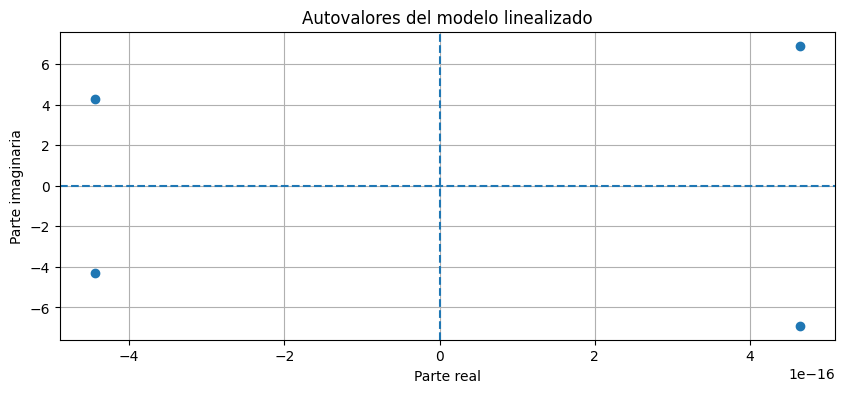

In [14]:
# ============================================================
# 14. Autovalores del sistema linealizado
# ============================================================

eigvals = np.linalg.eigvals(A_num)

print("Autovalores de A:")
for lam in eigvals:
    print(lam)

plt.figure()
plt.scatter(eigvals.real, eigvals.imag)
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.title("Autovalores del modelo linealizado")
plt.grid(True)
plt.show()

# 11. Simulación del modelo no lineal

Para comparar el modelo no lineal y el linealizado, definimos una dinámica numérica:

$$
\dot{\mathbf{x}}
=
\mathbf{f}(\mathbf{x},\mathbf{u})
$$

Usaremos una entrada constante igual al torque de equilibrio:

$$
\mathbf{u}(t)=\mathbf{u}_0
$$

y una condición inicial perturbada:

$$
\mathbf{x}(0)
=
\mathbf{x}_0
+
\Delta \mathbf{x}(0)
$$

Por ejemplo:

$$
\Delta\theta_h(0)=3^\circ
$$

$$
\Delta\theta_k(0)=-2^\circ
$$

In [15]:
# ============================================================
# 15. Lambdificar la dinámica no lineal
# ============================================================

vars_for_lambdify = (
    theta_h, theta_k, dtheta_h, dtheta_k,
    tau_h, tau_k,
    m_th, m_sh, l_th, l_sh, l_mt, l_ms, I_th, I_sh, g
)

f_lamb = sp.lambdify(vars_for_lambdify, f_sym, modules="numpy")

def nonlinear_dynamics(t, x, u):
    args = (
        x[0], x[1], x[2], x[3],
        u[0], u[1],
        param_values[m_th],
        param_values[m_sh],
        param_values[l_th],
        param_values[l_sh],
        param_values[l_mt],
        param_values[l_ms],
        param_values[I_th],
        param_values[I_sh],
        param_values[g],
    )
    dx = np.array(f_lamb(*args), dtype=float).reshape(-1)
    return dx

In [16]:
# ============================================================
# 16. Simular modelo no lineal alrededor del punto de operación
# ============================================================

t_span = (0.0, 2.5)
t_eval = np.linspace(t_span[0], t_span[1], 500)

delta_x0 = np.array([
    np.deg2rad(3.0),
    np.deg2rad(-2.0),
    0.0,
    0.0
])

x_initial = x0 + delta_x0

sol_nl = solve_ivp(
    fun=lambda t, x: nonlinear_dynamics(t, x, u0),
    t_span=t_span,
    y0=x_initial,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10
)

print("Simulación no lineal finalizada:", sol_nl.success)

Simulación no lineal finalizada: True


# 12. Simulación del modelo linealizado

El modelo linealizado describe perturbaciones:

$$
\delta\dot{\mathbf{x}}
=
\mathbf{A}\delta\mathbf{x}
+
\mathbf{B}\delta\mathbf{u}
$$

Si aplicamos el torque de equilibrio $\mathbf{u}_0$ en el modelo no lineal, entonces:

$$
\delta\mathbf{u}=0
$$

Por tanto, el modelo lineal queda:

$$
\delta\dot{\mathbf{x}}
=
\mathbf{A}\delta\mathbf{x}
$$

La trayectoria aproximada del modelo completo es:

$$
\mathbf{x}_{lin}(t)
=
\mathbf{x}_0
+
\delta\mathbf{x}(t)
$$

In [17]:
# ============================================================
# 17. Simular modelo linealizado
# ============================================================

sys_lin = StateSpace(A_num, B_num, C_num, D_num)

u_delta = np.zeros((len(t_eval), 2))

tout, y_delta, x_delta = lsim(
    system=sys_lin,
    U=u_delta,
    T=t_eval,
    X0=delta_x0
)

x_lin = x0 + x_delta

print("Simulación linealizada finalizada.")

Simulación linealizada finalizada.


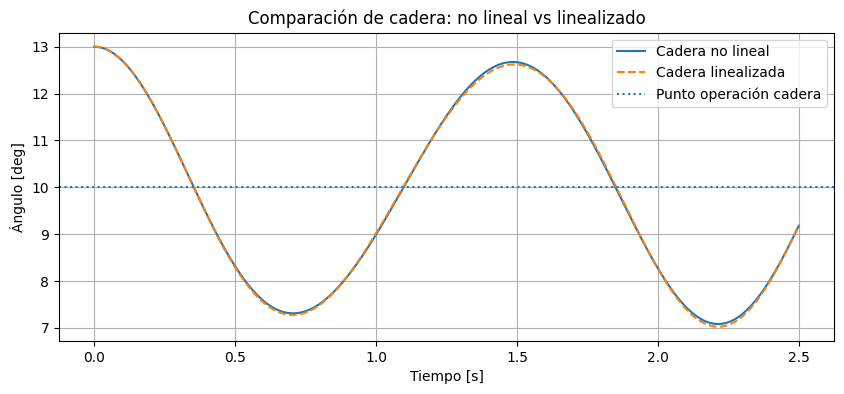

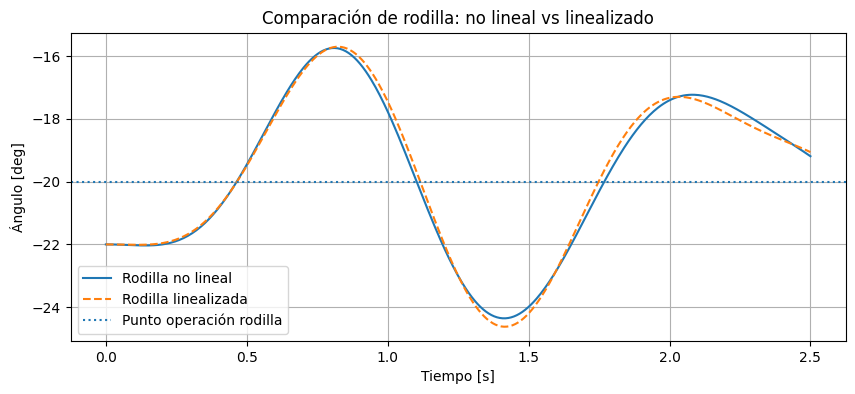

In [18]:
# ============================================================
# 18. Comparar respuesta no lineal vs linealizada
# ============================================================

theta_h_nl = sol_nl.y[0]
theta_k_nl = sol_nl.y[1]

theta_h_lin = x_lin[:, 0]
theta_k_lin = x_lin[:, 1]

plt.figure()
plt.plot(t_eval, np.rad2deg(theta_h_nl), label="Cadera no lineal")
plt.plot(t_eval, np.rad2deg(theta_h_lin), "--", label="Cadera linealizada")
plt.axhline(theta_h0_deg, linestyle=":", label="Punto operación cadera")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [deg]")
plt.title("Comparación de cadera: no lineal vs linealizado")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t_eval, np.rad2deg(theta_k_nl), label="Rodilla no lineal")
plt.plot(t_eval, np.rad2deg(theta_k_lin), "--", label="Rodilla linealizada")
plt.axhline(theta_k0_deg, linestyle=":", label="Punto operación rodilla")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [deg]")
plt.title("Comparación de rodilla: no lineal vs linealizado")
plt.grid(True)
plt.legend()
plt.show()

# 13. Discusión sobre validez de la linealización

La linealización es una aproximación local. Es confiable cuando:

$$
\|\delta\mathbf{x}\|
$$

es pequeña.

En otras palabras, el modelo linealizado representa bien al modelo no lineal únicamente cerca de:

$$
(\mathbf{x}_0,\mathbf{u}_0)
$$

Si la perturbación angular inicial es grande, si las velocidades son altas o si se aleja demasiado del punto de operación, aparecerán diferencias importantes entre ambas respuestas.

---

## 13.1. Qué representa físicamente el punto de operación

El punto:

$$
\mathbf{x}_0 =
\begin{bmatrix}
\theta_{h0}\\
\theta_{k0}\\
0\\
0
\end{bmatrix}
$$

representa una postura estática de la pierna.

El torque:

$$
\mathbf{u}_0 =
\mathbf{G}(\mathbf{q}_0)
$$

representa el torque necesario para sostener esa postura contra la gravedad.

---

## 13.2. Por qué esto es útil para control

La representación:

$$
\delta\dot{\mathbf{x}}
=
\mathbf{A}\delta\mathbf{x}
+
\mathbf{B}\delta\mathbf{u}
$$

permite diseñar controladores lineales como:

- realimentación de estados,
- ubicación de polos,
- LQR,
- observadores,
- control integral,
- control discreto.

Una vez diseñado el control incremental:

$$
\delta\mathbf{u}
=
-\mathbf{K}\delta\mathbf{x}
$$

la entrada real aplicada al sistema no lineal es:

$$
\mathbf{u}
=
\mathbf{u}_0
+
\delta\mathbf{u}
$$

# 14. Actividad complementaria: diseñar un control por realimentación de estados

Como extensión natural, se puede diseñar:

$$
\delta\mathbf{u}
=
-\mathbf{K}\delta\mathbf{x}
$$

de manera que:

$$
\delta\dot{\mathbf{x}}
=
(\mathbf{A}-\mathbf{B}\mathbf{K})
\delta\mathbf{x}
$$

El estudiante puede explorar:

1. Ubicación de polos.
2. Control LQR.
3. Control integral para seguimiento de referencias.
4. Comparación entre controlador lineal aplicado al modelo lineal y al modelo no lineal.

---

## Preguntas guía

1. ¿Qué variables son los estados del sistema?
2. ¿Por qué se requiere un torque de equilibrio $\mathbf{u}_0$?
3. ¿Qué cambia si se linealiza alrededor de otra postura?
4. ¿Qué significado físico tienen las matrices $\mathbf{A}$ y $\mathbf{B}$?
5. ¿Por qué el modelo linealizado solo es válido localmente?
6. ¿Cómo se extendería el modelo para incluir fuerzas de interacción humano-exoesqueleto?

# 15. Resumen final

En este notebook se construyó el modelo matemático de una pierna de exoesqueleto planar de dos grados de libertad.

El desarrollo siguió esta ruta:

1. Definición de coordenadas:
   $$
   \mathbf{q}=
   [\theta_h,\theta_k]^T
   $$

2. Cinemática de centros de masa.

3. Energías:
   $$
   T, \quad V, \quad L=T-V
   $$

4. Ecuaciones de Euler-Lagrange:
   $$
   \frac{d}{dt}\frac{\partial L}{\partial \dot{q}_i}
   -
   \frac{\partial L}{\partial q_i}
   =
   \tau_i
   $$

5. Forma dinámica:
   $$
   \mathbf{M}(\mathbf{q})\ddot{\mathbf{q}}
   +
   \mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\dot{\mathbf{q}}
   +
   \mathbf{G}(\mathbf{q})
   =
   \boldsymbol{\tau}
   $$

6. Representación no lineal:
   $$
   \dot{\mathbf{x}}=\mathbf{f}(\mathbf{x},\mathbf{u})
   $$

7. Linealización:
   $$
   \delta\dot{\mathbf{x}}
   =
   \mathbf{A}\delta\mathbf{x}
   +
   \mathbf{B}\delta\mathbf{u}
   $$

8. Simulación comparativa entre modelo no lineal y modelo linealizado.

Este procedimiento constituye la base para diseñar controladores de trayectoria, control óptimo, observadores y estrategias avanzadas para exoesqueletos de miembro inferior.